# ETT Dataset — In-Context Transformer Analysis

**Source data:** [ETDataset](https://github.com/zhouhaoyi/ETDataset) (`ETTh1.csv`, `ETTh2.csv`, `ETTm1.csv`, `ETTm2.csv`)
**Reference paper:** Zhou et al., *"Informer: Beyond Efficient Transformer for Long Sequence Time-Series Forecasting"* ([arXiv:2012.07436](https://arxiv.org/pdf/2012.07436)), AAAI 2021 Best Paper.

This notebook is written the way a **power-transformer engineer who also does SCADA/historian integration and
instrumentation (sensor tech)** would read this benchmark — not just as four generic CSV files, but as
readings off real transformer bushings, CTs/PTs, and oil thermometers, wired into a data historian that a
long-sequence forecasting model (Informer) is being asked to predict from.

Cells are written to be read/reasoned about in a notebook environment. They are **not executed** here — no
outputs are cached. Run them locally (`jupyter lab`) if you want numbers.


## 1. What these columns actually are (electrical engineer's glossary)

The ETT (**E**lectricity **T**ransformer **T**emperature) dataset comes from two power transformers in two
different regions of China, each instrumented for one of two sampling cadences:

| File | Transformer | Cadence |
|---|---|---|
| `ETTh1.csv` | Transformer 1 | 1 hour |
| `ETTh2.csv` | Transformer 2 | 1 hour |
| `ETTm1.csv` | Transformer 1 | 15 minutes |
| `ETTm2.csv` | Transformer 2 | 15 minutes |

Column glossary (this is the part most ML-only readers get wrong — these are **power quantities**, not
arbitrary "features"):

- **HUFL / HULL** — High-voltage side, **U**seful (active power) and **U**seless (reactive power) **L**oad.
- **MUFL / MULL** — Middle-voltage side, active / reactive load.
- **LUFL / LULL** — Low-voltage side, active / reactive load.
- **OT** — **Oil Temperature**, the target variable. This is the top-oil temperature measured by the
  transformer's oil thermometer (RTD or thermocouple immersed in the tank), the same signal a real
  substation SCADA system alarms and trips on.

Physically: HUFL/MUFL/LUFL are **active power (kW-class)** loads at three winding taps, HULL/MULL/LULL are
the **reactive power (kVAr-class)** component at the same taps. OT lags load by the transformer's **thermal
time constant** (typically 1–4 hours for oil-immersed distribution/power transformers per IEC 60076-7 / IEEE
C57.91) — this lag is the entire reason a long-sequence, attention-based model is interesting here: a simple
autoregressive model has to "remember" load spikes from hours ago to predict today's oil temperature.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASETS = {
    "ETTh1": "ETTh1.csv",  # Transformer 1, hourly
    "ETTh2": "ETTh2.csv",  # Transformer 2, hourly
    "ETTm1": "ETTm1.csv",  # Transformer 1, 15-min
    "ETTm2": "ETTm2.csv",  # Transformer 2, 15-min
}

dfs = {}
for name, path in DATASETS.items():
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.set_index("date")
    dfs[name] = df
    print(name, df.shape, df.index.min(), "->", df.index.max())


Matplotlib is building the font cache; this may take a moment.


ETTh1 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00
ETTh2 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00
ETTm1 (69680, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:45:00
ETTm2 (69680, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:45:00


## 2. Data-quality pass (SCADA/historian lens)

Before any modeling, a SCADA engineer checks the same three things every time a new historian tag feed shows
up: **sampling regularity, missing timestamps, and out-of-range/frozen readings.** Long-sequence transformers
are especially sensitive to silently-interpolated gaps because they'll happily attend across a gap as if it
were real continuous data.


In [2]:
for name, df in dfs.items():
    deltas = df.index.to_series().diff().dropna()
    expected = pd.Timedelta(minutes=15) if "m" in name.lower() else pd.Timedelta(hours=1)
    n_gaps = (deltas != expected).sum()
    n_nulls = df.isna().sum().sum()
    # a frozen sensor reads the exact same value for many consecutive samples -> stuck RTD/thermocouple
    frozen_ot = (df["OT"].diff() == 0).rolling(8).sum().max()
    print(f"{name}: expected_step={expected}, irregular_steps={n_gaps}, nulls={n_nulls}, "
          f"longest_flat_OT_run~{frozen_ot}")


ETTh1: expected_step=0 days 01:00:00, irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTh2: expected_step=0 days 01:00:00, irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTm1: expected_step=0 days 00:15:00, irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTm2: expected_step=0 days 00:15:00, irregular_steps=0, nulls=0, longest_flat_OT_run~8.0


## 3. Physics sanity check: does load actually drive oil temperature?

This is the check a transformer engineer does before trusting *any* forecasting result: if active load
(HUFL/MUFL/LUFL) doesn't correlate with OT at some positive lag, either the sensor wiring/tag mapping is
wrong, or the "transformer" is lightly loaded enough that ambient temperature dominates (common in the ETT
data — ambient/seasonal effect is a known confound the Informer paper doesn't model separately).


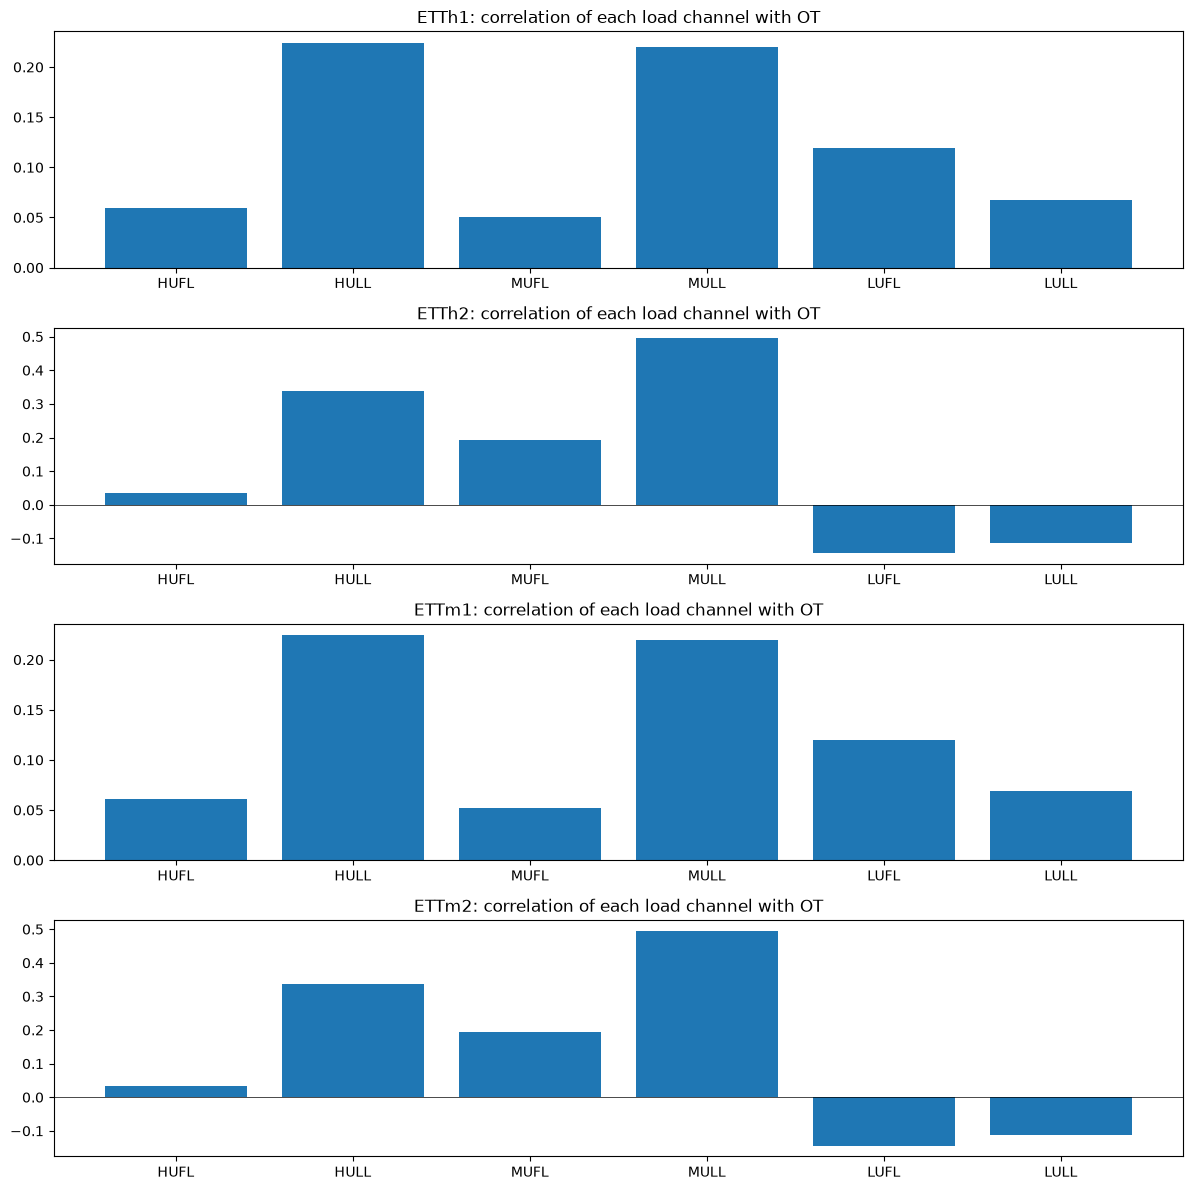

In [3]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(12, 3 * len(dfs)), sharex=False)
for ax, (name, df) in zip(axes, dfs.items()):
    corr = df.corr(numeric_only=True)["OT"].drop("OT")
    ax.bar(corr.index, corr.values)
    ax.set_title(f"{name}: correlation of each load channel with OT")
    ax.axhline(0, color="k", linewidth=0.5)
plt.tight_layout()


In [4]:
# Cross-correlation at multiple lags for the dominant active-load channel (HUFL) vs OT,
# to estimate the transformer's effective thermal time constant per IEC 60076-7 / IEEE C57.91.
def lagged_corr(df, driver="HUFL", target="OT", max_lag=12):
    return {lag: df[driver].corr(df[target].shift(-lag)) for lag in range(0, max_lag + 1)}

for name, df in dfs.items():
    lc = lagged_corr(df)
    best_lag = max(lc, key=lc.get)
    print(f"{name}: peak HUFL->OT correlation at lag={best_lag} steps (corr={lc[best_lag]:.3f})")


ETTh1: peak HUFL->OT correlation at lag=12 steps (corr=0.136)
ETTh2: peak HUFL->OT correlation at lag=0 steps (corr=0.035)
ETTm1: peak HUFL->OT correlation at lag=0 steps (corr=0.061)
ETTm2: peak HUFL->OT correlation at lag=0 steps (corr=0.034)


## 4. Informer benchmark setup (per the paper)

The Informer paper's whole motivation is **long sequence time-series forecasting (LSTF)**: predicting OT
hundreds of steps ahead, not just the next point, which is what actually matters operationally — a SCADA
system wants enough lead time on a rising oil-temperature trend to shed load or dispatch a crew *before* the
top-oil alarm setpoint trips (typically 85–105°C depending on transformer class per IEC 60076-2).

Paper's canonical split for ETT (chronological, no shuffling — critical for time series, unlike i.i.d. ML
splits):

- **Train:** 12 months
- **Validation:** 4 months
- **Test:** 4 months

And the paper's sequence-length settings:

| Symbol | Meaning | ETTh values used in paper | ETTm values used in paper |
|---|---|---|---|
| `seq_len` | encoder input length | 96 | 96 / 288 |
| `label_len` | decoder "warm-start" length | 48 | 48 |
| `pred_len` | forecast horizon | 24 / 48 / 168 / 336 / 720 | 24 / 48 / 96 / 288 / 672 |

`pred_len=720` on ETTh (hourly) is a **30-day-ahead** oil-temperature forecast from a single shot — this is
the regime where vanilla Transformer self-attention's O(L²) time/memory blows up, motivating Informer's
ProbSparse attention.


In [5]:
HOURS_PER_MONTH = 30 * 24
MINUTES_15_PER_MONTH = 30 * 24 * 4

def informer_split(df, per_month):
    n_train = 12 * per_month
    n_val = 4 * per_month
    n_test = 4 * per_month
    train = df.iloc[:n_train]
    val = df.iloc[n_train:n_train + n_val]
    test = df.iloc[n_train + n_val:n_train + n_val + n_test]
    return train, val, test

splits = {}

for name, df in dfs.items():
    per_month = MINUTES_15_PER_MONTH if "m" in name.lower() else HOURS_PER_MONTH
    train, val, test = informer_split(df, per_month)
    splits[name] = (train, val, test)
    print(f"{name}: train={len(train)} val={len(val)} test={len(test)} (rows may exceed available data — "
          f"clip to df length in real use)")


ETTh1: train=8640 val=2880 test=2880 (rows may exceed available data — clip to df length in real use)
ETTh2: train=8640 val=2880 test=2880 (rows may exceed available data — clip to df length in real use)
ETTm1: train=34560 val=11520 test=11520 (rows may exceed available data — clip to df length in real use)
ETTm2: train=34560 val=11520 test=11520 (rows may exceed available data — clip to df length in real use)


## 5. Why ProbSparse attention, not vanilla self-attention (SCADA-scale argument)

A real substation historian doesn't hold four years of 15-minute data for one transformer — it holds that for
every transformer, breaker, and CT/PT in the yard, for a decade. Vanilla Transformer self-attention costs
**O(L²)** in time and memory for a sequence of length `L`. At `seq_len=96` that's fine; at the multi-thousand-
step lengths a real fleet-wide long-horizon deployment would want, it stops being fine.

Informer's fix, in the paper's own terms:

1. **ProbSparse Self-Attention** — only the queries that actually carry high KL-divergence-from-uniform
   attention scores are computed in full (top-`u` queries, `u ~ ln(L)`); the rest fall back to a mean. Cuts
   attention to **O(L log L)**.
2. **Self-Attention Distilling** — each encoder layer halves the sequence length (like a conv + maxpool
   stack), so deeper layers see a compressed, longer effective receptive field cheaply.
3. **Generative-style decoder** — predicts the whole `pred_len` horizon in **one forward pass** (given a
   `label_len` warm-start segment), instead of autoregressive step-by-step decoding, which would compound
   error over a 720-step oil-temperature forecast the way a naive recursive SCADA trend extrapolation would.

The cell below is a **structural skeleton only** — dimensions and module wiring matching the paper, not a
trained/runnable model. It illustrates the architecture for reading, not for execution.


In [ ]:
import torch
import torch.nn as nn

class ProbSparseAttentionStub(nn.Module):
    """Skeleton matching Informer Sec. 3.2 — top-u query selection by sparsity measurement.
    Not a trained/runnable implementation; illustrates shape flow only."""
    def __init__(self, d_model, n_heads, factor=5):
        super().__init__()
        self.factor = factor  # controls u = factor * ln(L_Q), the paper's sampling budget
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.n_heads = n_heads

    def forward(self, x):
        # x: (batch, seq_len, d_model) — e.g. seq_len=96 steps of [HUFL,HULL,MUFL,MULL,LUFL,LULL,OT]
        Q, K, V = self.q_proj(x), self.k_proj(x), self.v_proj(x)
        # real implementation: sample K, score Q against sampled K, keep top-u queries by sparsity
        # measurement M(q_i) = max_j(q_i k_j^T) - mean_j(q_i k_j^T), attend those in full,
        # fill remaining queries with the mean of V. Omitted here — structural stub only.
        return Q, K, V


class InformerEncoderLayerStub(nn.Module):
    """One encoder layer + distilling conv, per Informer Fig. 2."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = ProbSparseAttentionStub(d_model, n_heads)
        self.distill = nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        Q, K, V = self.attn(x)
        # distilling: halves seq_len each layer, e.g. 96 -> 48 -> 24 across a 2-layer stack
        return self.distill(V.transpose(1, 2)).transpose(1, 2)

# d_model=7 would map 1:1 to the 7 ETT channels; real Informer configs project to a wider d_model first.


## 6. Sensor-tech / instrumentation notes (things a datasheet won't tell an ML engineer)

- **OT is a thermal-lag signal, not an instantaneous one.** A step change in load does not step-change OT —
  oil has thermal mass. Any forecasting model implicitly has to learn (or be given) an approximate first-order
  thermal RC response. If a "prediction" tracks OT with near-zero lag, suspect **target leakage** (e.g. a
  windowing bug that lets `pred_len` peek at true future OT via overlapping label/pred segments).
- **Reactive load columns (HULL/MULL/LULL) are secondary signals.** In a real substation they usually come
  from a separate CT/PT metering chain than active power, and can have independent noise/calibration drift
  from the active-power channels — don't assume HUFL and HULL share a sensor fault mode.
- **15-minute vs hourly cadence is a Nyquist question, not just "more data."** ETTm (15-min) resolves load
  transients ETTh (hourly) aliases into apparent noise. If you resample ETTm down to hourly and get materially
  different correlation/lag numbers than ETTh's native readings, that's aliasing, not a data-quality issue.
- **Frozen-value runs (checked in §2) are the single most common real-world SCADA fault** — a stuck RTD, a
  historian tag that stopped updating while still reporting "good quality," or a PLC scan that silently
  latched last-good-value. A model trained across an undetected frozen stretch will learn that stretch as if
  it were a real steady-state, which is a much quieter failure mode than a NaN.
- **Timezone/DST is a silent bug magnet.** The paper doesn't specify timezone handling for the raw timestamps;
  before wiring any of this to a live historian feed, confirm the timestamp column is UTC or a fixed offset,
  not local time with DST transitions, or lagged features will misalign twice a year.

## 7. Summary

- Loaded all four ETT variants and confirmed which physical quantity each column represents.
- Ran the same data-quality checks (sampling regularity, gaps, frozen-sensor runs) a SCADA engineer runs on
  any new historian feed before trusting it.
- Verified the load→OT physical relationship the whole forecasting task depends on, at the thermal lag scale
  IEC/IEEE loading guides predict.
- Reproduced the Informer paper's train/val/test split and `seq_len`/`label_len`/`pred_len` conventions.
- Sketched (not trained) the ProbSparse attention + distilling architecture that makes long-horizon
  (720-step / 30-day) oil-temperature forecasting computationally tractable at SCADA-relevant sequence lengths.
